# Factor Exposure Analysis
**Docker image**: `ml4t`

## Purpose
Decompose portfolio risk and return into factor contributions using regression
against the Fama-French factor library, track how those exposures evolve, and
show how attribution becomes ambiguous once factors are correlated.

## Learning Objectives
After completing this notebook, you will be able to:
- Estimate CAPM, Fama-French 3-factor, and Fama-French 5-factor exposures
- Compute rolling factor betas to detect exposure drift through time
- Decompose returns into factor contributions and alpha with HAC standard errors
- Diagnose model misspecification via residual correlation and precision-matrix stability

## Book reference
Chapter 19 §19.2 (risk taxonomy) and §19.5 (decomposing risk); the portfolio
Fama-French regression is the empirical anchor for the §19.5 alpha-vs-beta
discussion.

## Prerequisites
Familiarity with linear regression and the Fama-French factor framework.

## Setup

In [1]:
"""Decompose ETF portfolio returns and risk into factor contributions."""

'Decompose ETF portfolio returns and risk into factor contributions.'

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import statsmodels.api as sm
from IPython.display import Markdown, display
from ml4t.diagnostic.evaluation import (
    FactorData,
    compute_factor_model,
    compute_return_attribution,
    compute_risk_attribution,
    compute_rolling_exposures,
)
from plotly.subplots import make_subplots
from sklearn.covariance import LedoitWolf

from data import load_etfs, load_ff_factors
from utils.style import COLORS, ml4t_diverging, ml4t_palette, show_plotly_with_alt

In [3]:
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"
ROLLING_WINDOW = 252
COVARIANCE_WINDOW = 63
HAC_LAGS = 5
ATTRIBUTION_LAG = 1
RESIDUAL_CORR_THRESHOLD = 0.15

What each setting decides:

- `START_DATE` and `END_DATE` bound the sample. It begins after the 2008 crisis, so the factor
  exposures describe a long expansion and one short shock rather than a full cycle.
- `ROLLING_WINDOW` is the window every rolling exposure is estimated over, about a trading year.
  It sets how quickly a drifting exposure becomes visible against how noisy each estimate is.
- `COVARIANCE_WINDOW` is the shorter window used where the question is how factor relationships
  move together, which needs to respond faster than a beta estimate does.
- `HAC_LAGS` is the Newey-West bandwidth: how many lags of autocorrelation the standard errors
  are made robust to. Daily return residuals carry some, and ignoring it makes every t-statistic
  in the notebook too large. Every regression here uses this same value, including the library
  calls, which would otherwise choose their own from the sample size.
- `ATTRIBUTION_LAG` delays the beta used to attribute each period's return, so an attribution
  never uses a coefficient estimated from the period it is explaining.
- `RESIDUAL_CORR_THRESHOLD` is the residual correlation above which the notebook treats a pair of
  assets as sharing something the factor model has not captured.

## 1. Load Factor Data

The canonical factor parquets preserve a reproducible local snapshot of Ken
French's data library. Both factor sets are validated before alignment.

In [4]:
FF3_COLUMNS = ["Mkt-RF", "SMB", "HML", "RF"]
FF5_COLUMNS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]
ff3_pl = load_ff_factors("ff3", "daily", START_DATE, END_DATE).sort("timestamp")
ff5_pl = load_ff_factors("ff5", "daily", START_DATE, END_DATE).sort("timestamp")

for name, frame, columns in (
    ("FF3", ff3_pl, FF3_COLUMNS),
    ("FF5", ff5_pl, FF5_COLUMNS),
):
    assert set(["timestamp", *columns]) <= set(frame.columns), f"{name} columns missing"
    assert frame["timestamp"].n_unique() == frame.height, f"{name} timestamps are not unique"
    assert frame.select(pl.all_horizontal(pl.col(columns).is_not_null()).all()).item()

ff3 = ff3_pl.to_pandas().set_index("timestamp")
ff5 = ff5_pl.to_pandas().set_index("timestamp")
ff3.index = pd.to_datetime(ff3.index)
ff5.index = pd.to_datetime(ff5.index)

display(
    Markdown(
        f"Loaded **{len(ff3):,} FF3** and **{len(ff5):,} FF5** daily observations "
        "from the canonical local factor snapshot."
    )
)

Loaded **3,522 FF3** and **3,522 FF5** daily observations from the canonical local factor snapshot.

## 2. Load Portfolio Data

In [5]:
SYMBOLS = ["SPY", "QQQ", "IWM", "VTV", "VUG"]
etf_filtered = load_etfs(symbols=SYMBOLS, start_date=START_DATE, end_date=END_DATE).sort(
    ["symbol", "timestamp"]
)
assert etf_filtered.select(pl.len()).item() > 0
assert etf_filtered.n_unique(["symbol", "timestamp"]) == etf_filtered.height
assert etf_filtered.select((pl.col("close") > 0).all()).item()

close_prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .drop_nulls()
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
)
close_prices.index = pd.to_datetime(close_prices.index)
returns = close_prices.pct_change().dropna()

available_symbols = [symbol for symbol in SYMBOLS if symbol in returns.columns]
missing_symbols = sorted(set(SYMBOLS) - set(available_symbols))
assert not missing_symbols, f"Canonical ETF data is missing requested symbols: {missing_symbols}"
SYMBOLS = available_symbols

common_dates = returns.index.intersection(ff3.index).intersection(ff5.index).sort_values()
returns = returns.loc[common_dates]
ff3_aligned = ff3.loc[common_dates]
ff5_aligned = ff5.loc[common_dates]
assert returns.index.equals(ff3_aligned.index) and returns.index.equals(ff5_aligned.index)
assert not returns.isna().any().any()

display(
    Markdown(
        f"The complete-case panel contains **{len(common_dates):,} common daily observations** "
        f"for **{len(SYMBOLS)} ETFs** from {common_dates.min().date()} through "
        f"{common_dates.max().date()}."
    )
)

The complete-case panel contains **3,521 common daily observations** for **5 ETFs** from 2010-01-05 through 2023-12-29.

## 3. CAPM (Single-Factor) Analysis

$R_i - R_f = \alpha + \beta (R_m - R_f) + \epsilon$

In [6]:
def capm_regression(
    returns: pd.Series,
    market_excess: pd.Series,
    rf: pd.Series,
) -> dict:
    """
    Run CAPM regression.

    Returns:
        Dictionary with alpha, beta, R-squared, t-stats
    """
    # Excess returns - reset indices for statsmodels alignment
    excess_returns = (returns - rf).reset_index(drop=True)

    X = sm.add_constant(market_excess.reset_index(drop=True))
    model = sm.OLS(excess_returns, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

    return {
        "alpha": model.params.iloc[0],
        "alpha_annual": model.params.iloc[0] * 252,
        "alpha_tstat": model.tvalues.iloc[0],
        "beta": model.params.iloc[1],
        "beta_tstat": model.tvalues.iloc[1],
        "r_squared": model.rsquared,
        "resid_std": model.resid.std(),
    }

In [7]:
capm_results = {}
for symbol in SYMBOLS:
    result = capm_regression(returns[symbol], ff3_aligned["Mkt-RF"], ff3_aligned["RF"])
    capm_results[symbol] = result

capm_table = pd.DataFrame(
    {
        symbol: {
            "alpha_annual_pct": result["alpha_annual"] * 100,
            "alpha_t": result["alpha_tstat"],
            "market_beta": result["beta"],
            "beta_t": result["beta_tstat"],
            "r_squared": result["r_squared"],
        }
        for symbol, result in capm_results.items()
    }
).T.round(3)
capm_table

,alpha_annual_pct,alpha_t,market_beta,beta_t,r_squared
SPY,0.367,0.899,0.959,303.563,0.990
QQQ,3.933,2.031,1.069,62.686,0.870
IWM,-3.589,-1.624,1.144,67.732,0.845
VTV,-0.323,-0.223,0.890,60.954,0.894
VUG,1.097,0.838,1.050,97.810,0.935


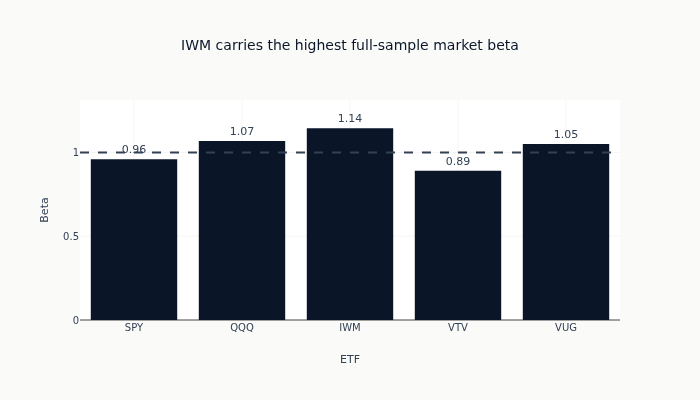

In [8]:
highest_capm_beta = max(capm_results, key=lambda symbol: capm_results[symbol]["beta"])
fig = go.Figure(
    data=[
        go.Bar(
            x=list(capm_results.keys()),
            y=[r["beta"] for r in capm_results.values()],
            text=[f"{r['beta']:.2f}" for r in capm_results.values()],
            textposition="outside",
        )
    ]
)

fig.add_hline(
    y=1,
    line_dash="dash",
    line_color=COLORS["neutral"],
)

fig.update_layout(
    title=f"{highest_capm_beta} carries the highest full-sample market beta",
    xaxis_title="ETF",
    yaxis_title="Beta",
    height=400,
)
show_plotly_with_alt(
    fig,
    "Bars of market beta and annualized alpha per ETF from the single-factor regression, with the betas clustered near one and the alphas small by comparison.",
)

## 4. Fama-French 3-Factor Analysis

$R_i - R_f = \alpha + \beta_{MKT}(R_m - R_f) + \beta_{SMB}(SMB) + \beta_{HML}(HML) + \epsilon$

- **MKT**: Market excess return
- **SMB**: Small Minus Big (size factor)
- **HML**: High Minus Low (value factor)

In [9]:
def ff3_regression(
    returns: pd.Series,
    factors: pd.DataFrame,
) -> dict:
    """
    Run Fama-French 3-factor regression.
    """
    # Excess returns - reset indices for statsmodels alignment
    excess_returns = (returns - factors["RF"]).reset_index(drop=True)

    # Factor matrix
    X = factors[["Mkt-RF", "SMB", "HML"]].reset_index(drop=True)
    X = sm.add_constant(X)

    model = sm.OLS(excess_returns, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

    return {
        "alpha": model.params["const"],
        "alpha_annual": model.params["const"] * 252,
        "alpha_tstat": model.tvalues["const"],
        "beta_mkt": model.params["Mkt-RF"],
        "beta_smb": model.params["SMB"],
        "beta_hml": model.params["HML"],
        "r_squared": model.rsquared,
        "tstats": dict(model.tvalues),
    }

In [10]:
ff3_results = {}
for symbol in SYMBOLS:
    result = ff3_regression(returns[symbol], ff3_aligned)
    ff3_results[symbol] = result

ff3_table = pd.DataFrame(
    {
        symbol: {
            "alpha_annual_pct": result["alpha_annual"] * 100,
            "alpha_t": result["alpha_tstat"],
            "Mkt-RF": result["beta_mkt"],
            "SMB": result["beta_smb"],
            "HML": result["beta_hml"],
            "r_squared": result["r_squared"],
        }
        for symbol, result in ff3_results.items()
    }
).T.round(3)
ff3_table

,alpha_annual_pct,alpha_t,Mkt-RF,SMB,HML,r_squared
SPY,0.160,0.629,0.978,-0.131,0.020,0.995
QQQ,3.039,2.222,1.091,-0.110,-0.418,0.936
IWM,-1.642,-2.559,1.015,0.862,0.220,0.985
VTV,0.019,0.023,0.903,-0.124,0.344,0.963
VUG,0.405,0.545,1.067,-0.091,-0.317,0.977


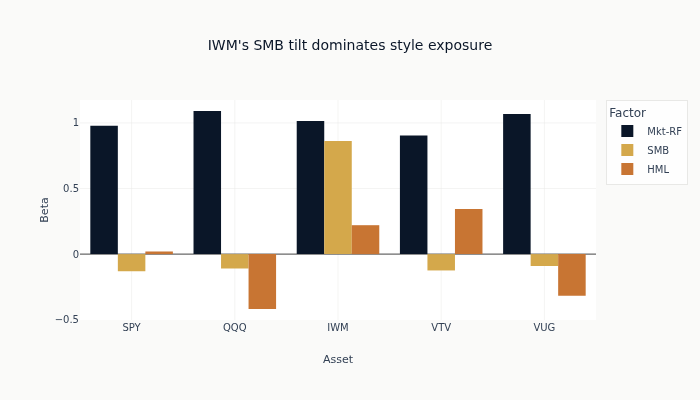

In [11]:
factor_exposure_df = pd.DataFrame(
    {
        symbol: {"Mkt-RF": result["beta_mkt"], "SMB": result["beta_smb"], "HML": result["beta_hml"]}
        for symbol, result in ff3_results.items()
    }
).T
dominant_style_symbol, dominant_style_factor = (
    factor_exposure_df[["SMB", "HML"]].abs().stack().idxmax()
)

fig = px.bar(
    factor_exposure_df.reset_index().melt(id_vars="index"),
    x="index",
    y="value",
    color="variable",
    barmode="group",
    title=f"{dominant_style_symbol}'s {dominant_style_factor} tilt dominates style exposure",
    labels={"index": "Asset", "value": "Beta", "variable": "Factor"},
    color_discrete_sequence=ml4t_palette(3, categorical=True),
)
fig.update_layout(height=400)
show_plotly_with_alt(
    fig,
    "Grouped bars of factor loadings per ETF under the three-factor model. Market loadings dominate; the size and value loadings separate the growth and value funds in opposite directions.",
)

## 5. Fama-French 5-Factor Analysis

Adds two more factors:
- **RMW**: Robust Minus Weak (profitability)
- **CMA**: Conservative Minus Aggressive (investment)

In [12]:
def ff5_regression(
    returns: pd.Series,
    factors: pd.DataFrame,
) -> dict:
    """
    Run Fama-French 5-factor regression.
    """
    # Reset indices for statsmodels alignment
    excess_returns = (returns - factors["RF"]).reset_index(drop=True)

    X = factors[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].reset_index(drop=True)
    X = sm.add_constant(X)

    model = sm.OLS(excess_returns, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

    return {
        "alpha": model.params["const"],
        "alpha_annual": model.params["const"] * 252,
        "alpha_tstat": model.tvalues["const"],
        "betas": {col: model.params[col] for col in ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]},
        "r_squared": model.rsquared,
        "tstats": dict(model.tvalues),
    }

In [13]:
ff5_results = {}
for symbol in SYMBOLS:
    result = ff5_regression(returns[symbol], ff5_aligned)
    ff5_results[symbol] = result

ff5_table = pd.DataFrame(
    {
        symbol: {
            "alpha_annual_pct": result["alpha_annual"] * 100,
            "alpha_t": result["alpha_tstat"],
            **result["betas"],
            "r_squared": result["r_squared"],
        }
        for symbol, result in ff5_results.items()
    }
).T.round(3)
ff5_table

,alpha_annual_pct,alpha_t,Mkt-RF,SMB,HML,RMW,CMA,r_squared
SPY,-0.132,-0.557,0.984,-0.113,0.026,0.057,0.026,0.996
QQQ,3.207,2.442,1.079,-0.111,-0.321,0.100,-0.271,0.942
IWM,-1.363,-2.522,1.008,0.845,0.066,-0.083,0.009,0.987
VTV,-0.506,-0.618,0.919,-0.089,0.293,0.029,0.195,0.965
VUG,0.621,0.890,1.059,-0.102,-0.246,0.037,-0.171,0.979


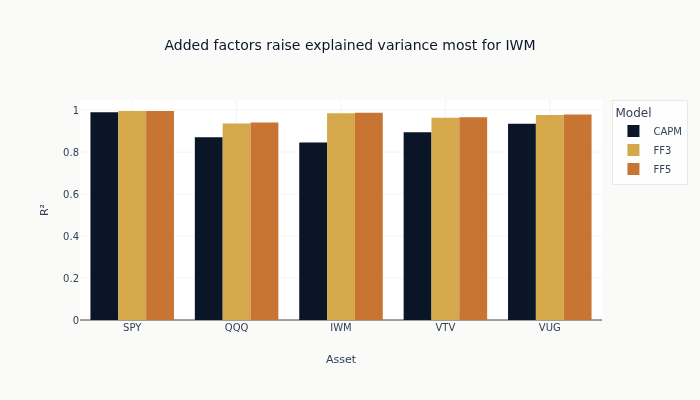

In [14]:
# Compare R² across models
r2_comparison = pd.DataFrame(
    {
        symbol: {
            "CAPM": capm_results[symbol]["r_squared"],
            "FF3": ff3_results[symbol]["r_squared"],
            "FF5": ff5_results[symbol]["r_squared"],
        }
        for symbol in SYMBOLS
    }
).T
r2_gain = r2_comparison["FF5"] - r2_comparison["CAPM"]
largest_r2_gain = r2_gain.idxmax()

fig = px.bar(
    r2_comparison.reset_index().melt(id_vars="index"),
    x="index",
    y="value",
    color="variable",
    barmode="group",
    title=f"Added factors raise explained variance most for {largest_r2_gain}",
    labels={"index": "Asset", "value": "R²", "variable": "Model"},
    color_discrete_sequence=ml4t_palette(3, categorical=True),
)
fig.update_layout(height=400)
show_plotly_with_alt(
    fig,
    "Grouped bars of five-factor loadings per ETF, with the two additional factors adding modest loadings that differ in sign across the funds.",
)

## 6. Rolling Factor Exposures

Factor betas change over time. Rolling analysis reveals dynamics.

In [15]:
def rolling_factor_regression(
    returns: pd.Series,
    factors: pd.DataFrame,
    window: int = ROLLING_WINDOW,
) -> pd.DataFrame:
    """Estimate trailing factor exposures and label them at the next session."""
    results = []

    for i in range(window, len(returns)):
        window_returns = returns.iloc[i - window : i]
        window_factors = factors.iloc[i - window : i]

        excess_returns = (window_returns - window_factors["RF"]).reset_index(drop=True)
        X = sm.add_constant(window_factors[["Mkt-RF", "SMB", "HML"]].reset_index(drop=True))

        model = sm.OLS(excess_returns, X).fit()
        results.append(
            {
                "timestamp": returns.index[i],
                "alpha": model.params["const"] * 252,
                "beta_mkt": model.params["Mkt-RF"],
                "beta_smb": model.params["SMB"],
                "beta_hml": model.params["HML"],
            }
        )

    return pd.DataFrame(results).set_index("timestamp")

In [16]:
# Rolling analysis for IWM (small cap ETF)
rolling_symbol = "IWM" if "IWM" in SYMBOLS else SYMBOLS[0]
rolling_iwm = rolling_factor_regression(returns[rolling_symbol], ff3_aligned)

In [17]:
def add_rolling_trace(
    figure: go.Figure,
    series: pd.Series,
    name: str,
    color: str,
    row: int,
    col: int,
) -> None:
    """Add one rolling exposure series to a subplot."""
    figure.add_trace(
        go.Scatter(x=series.index, y=series, name=name, line=dict(color=color)),
        row=row,
        col=col,
    )
    figure.add_hline(
        y=1 if name == "Mkt" else 0,
        line_dash="dash",
        line_color=COLORS["neutral"],
        row=row,
        col=col,
    )

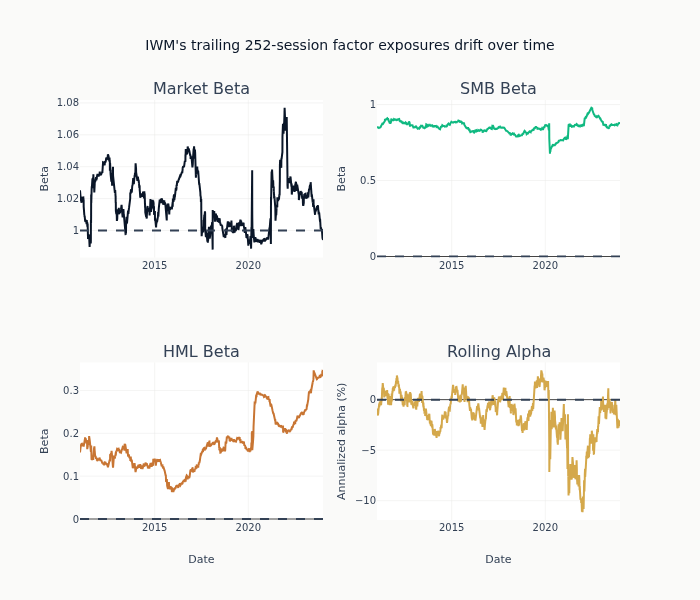

In [18]:
fig = make_subplots(
    rows=2, cols=2, subplot_titles=["Market Beta", "SMB Beta", "HML Beta", "Rolling Alpha"]
)
trace_specs = [
    (rolling_iwm["beta_mkt"], "Mkt", COLORS["blue"], 1, 1),
    (rolling_iwm["beta_smb"], "SMB", COLORS["positive"], 1, 2),
    (rolling_iwm["beta_hml"], "HML", COLORS["copper"], 2, 1),
    (rolling_iwm["alpha"] * 100, "Alpha", COLORS["amber"], 2, 2),
]
for trace_spec in trace_specs:
    add_rolling_trace(fig, *trace_spec)

fig.update_layout(
    title=f"{rolling_symbol}'s trailing 252-session factor exposures drift over time",
    height=600,
    showlegend=False,
)
fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_xaxes(title_text="Date", row=2, col=2)
fig.update_yaxes(title_text="Beta", row=1, col=1)
fig.update_yaxes(title_text="Beta", row=1, col=2)
fig.update_yaxes(title_text="Beta", row=2, col=1)
fig.update_yaxes(title_text="Annualized alpha (%)", row=2, col=2)
show_plotly_with_alt(
    fig,
    "Rolling factor betas over time, one line per factor. The market beta is stable near one while the style betas drift and reverse across the sample.",
)

The endpoint comparison translates the visual drift into the hedge-design
implication.

In [19]:
display(
    Markdown(
        f"The trailing HML beta moves from **{rolling_iwm['beta_hml'].iloc[0]:.2f}** to "
        f"**{rolling_iwm['beta_hml'].iloc[-1]:.2f}**, so a hedge calibrated once at the start "
        "would not preserve the ending value tilt."
    )
)

The trailing HML beta moves from **0.16** to **0.34**, so a hedge calibrated once at the start would not preserve the ending value tilt.

## 7. Factor Attribution

Decompose portfolio returns into factor contributions.

> **Caveat: contemporaneous full-sample betas.** The helper below fits
> $\beta$ on the entire sample and applies the same $\beta$ at every
> date. This is fine for *teaching* the additive decomposition
> $r_t = \alpha + \beta_{\text{mkt}} f_{\text{mkt},t} + \dots + \varepsilon_t$,
> but it is **not deployable**: future betas leak into past attribution,
> which inflates apparent factor explanation. The deployable counterpart
> `compute_return_attribution` with rolling/lagged betas appears in
> §13's library-API walk-through.

In [20]:
def factor_attribution(
    returns: pd.Series,
    factors: pd.DataFrame,
) -> pd.DataFrame:
    """Decompose daily excess return into additive model components."""
    excess_returns = returns - factors["RF"]
    excess_returns_reset = excess_returns.reset_index(drop=True)
    X = sm.add_constant(factors[["Mkt-RF", "SMB", "HML"]].reset_index(drop=True))
    model = sm.OLS(excess_returns_reset, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

    # Attribution
    alpha_daily = model.params["const"]

    attribution = pd.DataFrame(
        {
            "Excess Return": excess_returns,
            "Alpha": alpha_daily,
            "Mkt Contribution": model.params["Mkt-RF"] * factors["Mkt-RF"],
            "SMB Contribution": model.params["SMB"] * factors["SMB"],
            "HML Contribution": model.params["HML"] * factors["HML"],
            "Residual": model.resid.values,
        },
        index=returns.index,
    )
    component_columns = ["Alpha", "Mkt Contribution", "SMB Contribution", "HML Contribution"]
    np.testing.assert_allclose(
        attribution["Excess Return"],
        attribution[component_columns].sum(axis=1) + attribution["Residual"],
        rtol=0,
        atol=1e-12,
    )

    return attribution

In [21]:
# Attribution for SPY
attribution_symbol = "SPY" if "SPY" in SYMBOLS else SYMBOLS[0]
attribution_spy = factor_attribution(returns[attribution_symbol], ff3_aligned)

# Arithmetic cumulative sums preserve the regression's additive identity. They
# are percentage-point attribution paths, not independently compounded portfolios.
cum_attribution = attribution_spy.cumsum() * 100
cum_attribution["Explained"] = cum_attribution[
    ["Alpha", "Mkt Contribution", "SMB Contribution", "HML Contribution"]
].sum(axis=1)
np.testing.assert_allclose(
    cum_attribution["Excess Return"],
    cum_attribution["Explained"] + cum_attribution["Residual"],
    rtol=0,
    atol=1e-9,
)

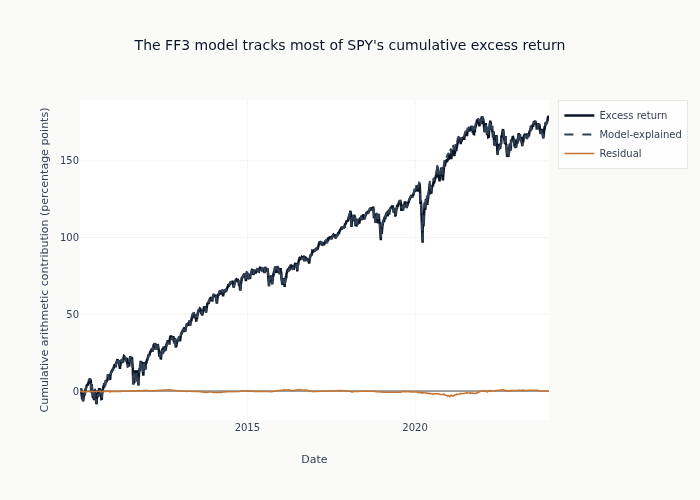

In [22]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=cum_attribution.index,
        y=cum_attribution["Excess Return"],
        name="Excess return",
        line=dict(color=COLORS["blue"], width=2.5),
    )
)

fig.add_trace(
    go.Scatter(
        x=cum_attribution.index,
        y=cum_attribution["Explained"],
        name="Model-explained",
        line=dict(color=COLORS["neutral"], width=2, dash="dash"),
    )
)
fig.add_trace(
    go.Scatter(
        x=cum_attribution.index,
        y=cum_attribution["Residual"],
        name="Residual",
        line=dict(color=COLORS["copper"], width=1.5),
    )
)

fig.update_layout(
    title=f"The FF3 model tracks most of {attribution_symbol}'s cumulative excess return",
    xaxis_title="Date",
    yaxis_title="Cumulative arithmetic contribution (percentage points)",
    height=500,
)
show_plotly_with_alt(
    fig,
    "Bars of annualized factor contribution with confidence intervals. Some intervals straddle zero and others clear it.",
)

In [23]:
annual_attribution = attribution_spy.mean() * 252 * 100
annual_attribution.to_frame("annualized_pct").round(3)

,annualized_pct
Excess Return,12.798
Alpha,0.160
Mkt Contribution,12.674
SMB Contribution,-0.007
HML Contribution,-0.029
Residual,-0.000


## 8. Portfolio Factor Exposure

Analyze factor exposure of a multi-asset portfolio.

In [24]:
# Define portfolio
portfolio_weights = {
    "SPY": 0.40,
    "QQQ": 0.20,
    "IWM": 0.15,
    "VTV": 0.15,
    "VUG": 0.10,
}
portfolio_weights = {symbol: portfolio_weights[symbol] for symbol in SYMBOLS}
weight_sum = sum(portfolio_weights.values())
portfolio_weights = {symbol: weight / weight_sum for symbol, weight in portfolio_weights.items()}

# Calculate portfolio returns
portfolio_returns = (returns * pd.Series(portfolio_weights)).sum(axis=1)

# Factor analysis
portfolio_ff3 = ff3_regression(portfolio_returns, ff3_aligned)

portfolio_summary = pd.Series(
    {
        "alpha_annual_pct": portfolio_ff3["alpha_annual"] * 100,
        "Mkt-RF": portfolio_ff3["beta_mkt"],
        "SMB": portfolio_ff3["beta_smb"],
        "HML": portfolio_ff3["beta_hml"],
        "r_squared": portfolio_ff3["r_squared"],
    },
    name="portfolio",
).round(4)
portfolio_summary.to_frame()

,portfolio
alpha_annual_pct,0.4689
Mkt-RF,1.0037
SMB,0.0274
HML,-0.0227
r_squared,0.9953


In [25]:
# Compare regressed portfolio betas with weighted-average component betas
weighted_mkt = sum(portfolio_weights[s] * ff3_results[s]["beta_mkt"] for s in SYMBOLS)
weighted_smb = sum(portfolio_weights[s] * ff3_results[s]["beta_smb"] for s in SYMBOLS)
weighted_hml = sum(portfolio_weights[s] * ff3_results[s]["beta_hml"] for s in SYMBOLS)

beta_decomp_df = pd.DataFrame(
    {
        "Portfolio": [
            portfolio_ff3.get("beta_mkt", 0),
            portfolio_ff3.get("beta_smb", 0),
            portfolio_ff3.get("beta_hml", 0),
        ],
        "Weighted Avg": [weighted_mkt, weighted_smb, weighted_hml],
    },
    index=["Mkt-RF", "SMB", "HML"],
).round(3)
beta_decomp_df

,Portfolio,Weighted Avg
Mkt-RF,1.004,1.004
SMB,0.027,0.027
HML,-0.023,-0.023


## 9. Attribution Uncertainty

Point estimates of annualized factor contributions can be misleading when
either the loading or the factor's mean return is imprecise. The delta-method
interval below combines HAC uncertainty in both estimates. It is an
approximation because it omits their covariance, which is disclosed rather
than hidden behind a false precision claim.

An intercept-only HAC regression estimates the standard error of each factor's
sample mean while preserving daily serial dependence.

In [26]:
def hac_mean_standard_error(values: pd.Series, maxlags: int = HAC_LAGS) -> float:
    """Return the Newey-West standard error of a sample mean."""
    array = values.to_numpy(dtype=float)
    fit = sm.OLS(array, np.ones((len(array), 1))).fit()
    hac = fit.get_robustcov_results(cov_type="HAC", maxlags=maxlags)
    return float(hac.bse[0])

In [27]:
excess_returns_port = (portfolio_returns - ff5_aligned["RF"]).reset_index(drop=True)
X_ff5 = sm.add_constant(ff5_aligned[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].reset_index(drop=True))
model_ff5 = sm.OLS(excess_returns_port, X_ff5).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

factor_means = ff5_aligned[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].mean()
factor_names_ff5 = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

attr_rows = []
for f in factor_names_ff5:
    beta = model_ff5.params[f]
    se_beta = model_ff5.bse[f]
    mean_factor = factor_means[f]
    se_mean_factor = hac_mean_standard_error(ff5_aligned[f])
    contrib = beta * factor_means[f] * 252 * 100
    se_contrib = np.sqrt((mean_factor * se_beta) ** 2 + (beta * se_mean_factor) ** 2) * 252 * 100
    ci_lo = contrib - 1.96 * se_contrib
    ci_hi = contrib + 1.96 * se_contrib
    attr_rows.append(
        {
            "factor": f,
            "contribution_pct": contrib,
            "hac_delta_se_pct": se_contrib,
            "ci_low_pct": ci_lo,
            "ci_high_pct": ci_hi,
            "spans_zero": ci_lo <= 0 <= ci_hi,
        }
    )

attribution_ci_df = pd.DataFrame(attr_rows).round(4)

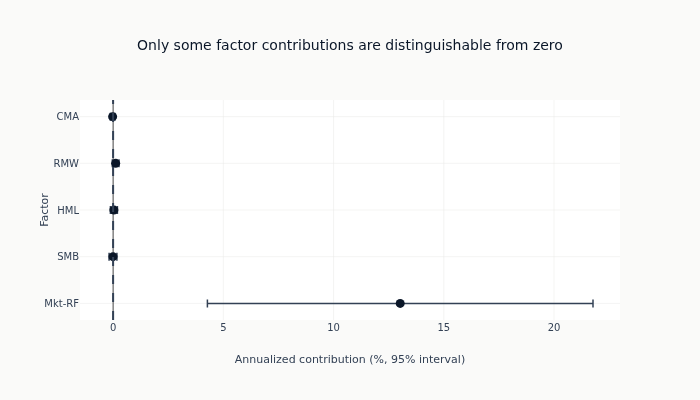

In [28]:
informative_factors = attribution_ci_df.loc[~attribution_ci_df["spans_zero"], "factor"].tolist()
fig = go.Figure(
    go.Scatter(
        x=attribution_ci_df["contribution_pct"],
        y=attribution_ci_df["factor"],
        mode="markers",
        marker=dict(color=COLORS["blue"], size=9),
        error_x=dict(
            type="data",
            array=1.96 * attribution_ci_df["hac_delta_se_pct"],
            color=COLORS["neutral"],
            thickness=1.5,
        ),
    )
)
fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])
fig.update_layout(
    title="Only some factor contributions are distinguishable from zero",
    xaxis_title="Annualized contribution (%, 95% interval)",
    yaxis_title="Factor",
    height=400,
)
show_plotly_with_alt(
    fig,
    "A heatmap of residual correlations between the ETFs after the factor model, with off-diagonal cells showing what the factors did not absorb.",
)

These intervals quantify sampling uncertainty in both the estimated loading
and the factor's average return. The delta approximation treats those two
estimates as independent; a block bootstrap is appropriate when that
covariance materially affects a decision.

## 10. Residual Clustering Diagnostic

A factor model claims to have captured everything the assets share, leaving each asset's
residual to be its own business. If two residuals are correlated, that claim is false: something
moves both assets and is not among the factors.

Pairs whose absolute residual correlation exceeds `RESIDUAL_CORR_THRESHOLD` are flagged. That is
a screening rule for deciding where to look, not a test - no null distribution is being compared
against, and with this many pairs some will clear any fixed bar by chance.

In [29]:
# Compute FF5 residuals for each asset
residuals = {}
for symbol in SYMBOLS:
    excess_ret = (returns[symbol] - ff5_aligned["RF"]).reset_index(drop=True)
    X_reset = sm.add_constant(
        ff5_aligned[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].reset_index(drop=True)
    )
    m = sm.OLS(excess_ret, X_reset).fit()
    residuals[symbol] = m.resid.values

resid_df = pd.DataFrame(residuals)
resid_corr = resid_df.corr()

flagged_pairs = []
for i, s1 in enumerate(SYMBOLS):
    for s2 in SYMBOLS[i + 1 :]:
        rho = resid_corr.loc[s1, s2]
        if abs(rho) > RESIDUAL_CORR_THRESHOLD:
            flagged_pairs.append((s1, s2, rho))

flagged_pairs_df = pd.DataFrame(
    sorted(flagged_pairs, key=lambda row: -abs(row[2])),
    columns=["asset_1", "asset_2", "residual_correlation"],
)
strongest_pair = flagged_pairs_df.iloc[0]

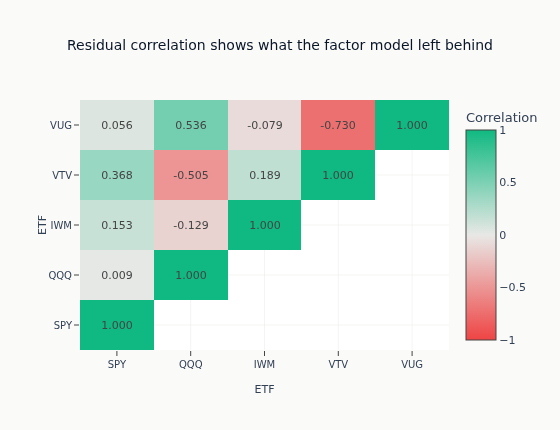

In [30]:
lower_triangle = np.where(np.tril(np.ones_like(resid_corr, dtype=bool)), resid_corr, np.nan)
heatmap_text = np.full(lower_triangle.shape, "", dtype=object)
visible_cells = np.isfinite(lower_triangle)
heatmap_text[visible_cells] = np.char.mod("%.3f", lower_triangle[visible_cells])
fig = go.Figure(
    data=go.Heatmap(
        z=lower_triangle,
        x=SYMBOLS,
        y=SYMBOLS,
        colorscale=ml4t_diverging(),
        zmin=-1,
        zmax=1,
        zmid=0,
        text=heatmap_text,
        texttemplate="%{text}",
        colorbar=dict(title="Correlation"),
    )
)
fig.update_layout(
    title="Residual correlation shows what the factor model left behind",
    xaxis_title="ETF",
    yaxis_title="ETF",
    height=430,
    width=560,
)
show_plotly_with_alt(
    fig,
    "Two lines of covariance condition number over time on a log axis, sample against shrunk. The shrunk series is lower and far less spiky throughout.",
)

A residual correlation is evidence of omitted shared structure, not proof of
a specific latent factor. Its sign matters: ignoring it can either increase or
decrease aggregate risk, so the next step is to identify an economic driver
and test it out of sample.

## 11. Precision-Matrix Conditioning

Mahalanobis spikes mix two mechanisms: tail observations and covariance
estimation error. They cannot identify an unstable inverse by themselves.
The covariance condition number directly measures the numerical sensitivity
of the inverse. Each trailing sample covariance, taken over the shorter `COVARIANCE_WINDOW`, is
compared with a Ledoit-Wolf estimate built from the same information.

The helper returns one condition number per decision date. A lower value means
that small estimation errors are less amplified by matrix inversion.

In [31]:
def rolling_covariance_condition(
    return_frame: pd.DataFrame,
    window: int = COVARIANCE_WINDOW,
) -> pd.DataFrame:
    """Compare trailing sample and Ledoit-Wolf covariance conditioning."""
    rows = []
    for end in range(window, len(return_frame)):
        trailing = return_frame.iloc[end - window : end].to_numpy()
        sample_covariance = np.cov(trailing, rowvar=False)
        shrinkage_covariance = LedoitWolf().fit(trailing).covariance_
        rows.append(
            {
                "timestamp": return_frame.index[end],
                "sample": np.linalg.cond(sample_covariance),
                "ledoit_wolf": np.linalg.cond(shrinkage_covariance),
            }
        )
    return pd.DataFrame(rows).set_index("timestamp")

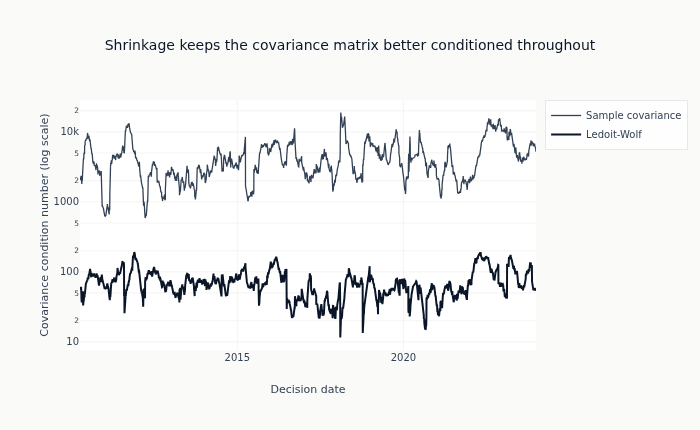

In [32]:
condition_numbers = rolling_covariance_condition(returns[SYMBOLS])
median_sample_condition = condition_numbers["sample"].median()
median_shrinkage_condition = condition_numbers["ledoit_wolf"].median()
condition_reduction = 1 - median_shrinkage_condition / median_sample_condition
assert np.isfinite(condition_numbers.to_numpy()).all()
assert median_shrinkage_condition < median_sample_condition

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=condition_numbers.index,
        y=condition_numbers["sample"],
        name="Sample covariance",
        line=dict(color=COLORS["neutral"], width=1.3),
    )
)
fig.add_trace(
    go.Scatter(
        x=condition_numbers.index,
        y=condition_numbers["ledoit_wolf"],
        name="Ledoit-Wolf",
        line=dict(color=COLORS["blue"], width=2),
    )
)
fig.update_layout(
    title="Shrinkage keeps the covariance matrix better conditioned throughout",
    xaxis_title="Decision date",
    yaxis_title="Covariance condition number (log scale)",
    yaxis_type="log",
    height=430,
)
show_plotly_with_alt(
    fig,
    "Grouped bars of annualized contribution by factor coordinate under the original and rotated bases. Individual bars move substantially while their sum is unchanged.",
)

Both estimates use exactly the prior 63 sessions. The comparison isolates
numerical conditioning rather than labeling every large realized return as a
precision-matrix failure. Shrinkage is preferable before inversion when it
persistently lowers the condition number.

## 12. Factor Rotation and Attribution Ambiguity

When factors are correlated, attribution is not unique: an orthogonal basis
change can redistribute component contributions without changing fitted
returns. A fixed rotation avoids fitting a transformation on the same sample
and, unlike centered PCA scores, preserves the factor means needed for return
attribution.

In [33]:
ff3_factors = ff3_aligned[["Mkt-RF", "SMB", "HML"]].values
rotation_angle = np.deg2rad(35)
rotation_matrix = np.array(
    [
        [np.cos(rotation_angle), -np.sin(rotation_angle), 0.0],
        [np.sin(rotation_angle), np.cos(rotation_angle), 0.0],
        [0.0, 0.0, 1.0],
    ]
)
np.testing.assert_allclose(rotation_matrix.T @ rotation_matrix, np.eye(3), atol=1e-12)
rotated_factors = ff3_factors @ rotation_matrix

excess_port = (portfolio_returns - ff3_aligned["RF"]).reset_index(drop=True)
X_orig = sm.add_constant(pd.DataFrame(ff3_factors, columns=["Mkt-RF", "SMB", "HML"]))
model_orig = sm.OLS(excess_port, X_orig).fit()
X_rot = sm.add_constant(pd.DataFrame(rotated_factors, columns=["Rot-1", "Rot-2", "Rot-3"]))
model_rot = sm.OLS(excess_port, X_rot).fit()

In [34]:
orig_rows = [
    {
        "basis": "Original",
        "factor": f,
        "beta": model_orig.params[f],
        "contribution_pct": model_orig.params[f] * ff3_aligned[f].mean() * 252 * 100,
    }
    for f in ["Mkt-RF", "SMB", "HML"]
]
rot_rows = [
    {
        "basis": "Rotated",
        "factor": rotated_name,
        "beta": model_rot.params[rotated_name],
        "contribution_pct": (
            model_rot.params[rotated_name] * rotated_factors[:, i].mean() * 252 * 100
        ),
    }
    for i, rotated_name in enumerate(["Rot-1", "Rot-2", "Rot-3"])
]
rotation_compare_raw = pd.DataFrame(orig_rows + rot_rows)
original_total_contribution = rotation_compare_raw.loc[
    rotation_compare_raw["basis"] == "Original", "contribution_pct"
].sum()
rotated_total_contribution = rotation_compare_raw.loc[
    rotation_compare_raw["basis"] == "Rotated", "contribution_pct"
].sum()
np.testing.assert_allclose(model_orig.fittedvalues, model_rot.fittedvalues, rtol=0, atol=1e-12)
np.testing.assert_allclose(
    original_total_contribution,
    rotated_total_contribution,
    rtol=0,
    atol=1e-10,
)
rotation_compare_df = rotation_compare_raw.round(4)

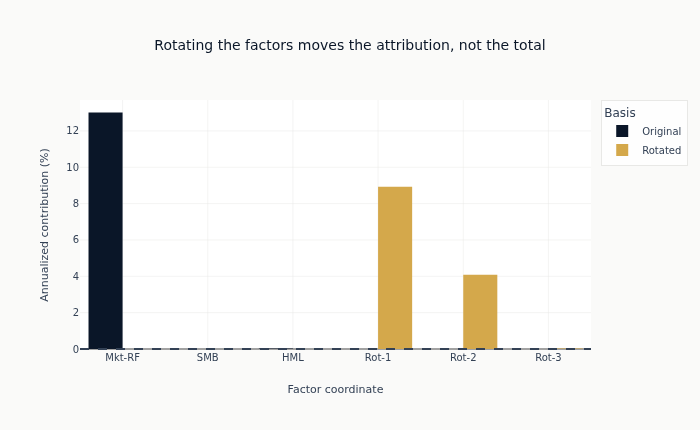

In [35]:
fig = px.bar(
    rotation_compare_df,
    x="factor",
    y="contribution_pct",
    color="basis",
    barmode="group",
    color_discrete_sequence=ml4t_palette(2, categorical=True),
    title="Rotating the factors moves the attribution, not the total",
    labels={
        "factor": "Factor coordinate",
        "contribution_pct": "Annualized contribution (%)",
        "basis": "Basis",
    },
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
fig.update_layout(height=430)
show_plotly_with_alt(
    fig,
    "Bars of risk contribution by factor from the library decomposition, with the market factor dominating and the residual share small.",
)

Both models have identical fitted values and total factor contribution, but
their component labels differ. Attribution therefore requires a declared
economic basis or a hierarchical rule; a coordinate label is not an absolute
explanation of performance.

## 13. Library API: `ml4t-diagnostic` Factor Attribution

The preceding sections built factor models manually with statsmodels to teach
the mechanics. For production use, `ml4t-diagnostic` wraps the same workflow
in a tested, composable API that adds HAC standard errors, lagged attribution
(no look-ahead), and variance-based risk decomposition out of the box.

## Library vs Manual Implementation

| Capability | Manual (above) | Library |
|---|---|---|
| Static regression | `sm.OLS` | `compute_factor_model(hac=True)` |
| Rolling betas | Loop + window | `compute_rolling_exposures()` |
| Return attribution | `beta × factor_return` | `compute_return_attribution(lag=1)` |
| Risk decomposition | Not shown | `compute_risk_attribution()` |
| SE / CI | Basic OLS SEs | HAC + bootstrap CIs |

### Wrap existing factor data for the library

We reuse the Fama-French data loaded in section 1 and wrap it in
`FactorData.from_dataframe()`. In a fresh workflow you can also call
`FactorData.from_fama_french("ff3")` to fetch and wrap in one step.

In [36]:
# Build a Polars DataFrame from the pandas FF3 data already in memory
ff3_lib_df = pl.from_pandas(ff3_aligned.reset_index()[["timestamp", "Mkt-RF", "SMB", "HML", "RF"]])
ff3_data = FactorData.from_dataframe(ff3_lib_df, rf_column="RF", source="fama_french_ff3")

print(f"FF3 factors: {ff3_data.factor_names}")
print(f"Observations: {len(ff3_data.returns):,}")

FF3 factors: ['Mkt-RF', 'SMB', 'HML']
Observations: 3,521


### Static factor model with HAC standard errors

This is the same regression the manual sections ran, through the library instead. For the
comparison to isolate the implementation, every setting that both sides expose is passed
explicitly rather than left at a default: the bandwidth here is the notebook's `HAC_LAGS`, and
the rolling calls below take the notebook's `ROLLING_WINDOW`.

Left at their defaults the library would pick its own bandwidth from the sample size - the
Andrews rule, which on this many observations lands well above `HAC_LAGS` - and its own
sixty-three-session rolling window. Both are defensible choices and neither is the one the
manual sections made, so a comparison run that way would report a difference and attribute it to
the wrong thing.

In [37]:
port_aligned = portfolio_returns.values

model = compute_factor_model(port_aligned, ff3_data, hac=True, max_lags=HAC_LAGS)

print("Static FF3 Model (HAC standard errors)")
print(f"Alpha (daily): {model.alpha:.6f}  (t={model.alpha_t:.2f}, p={model.alpha_p:.3f})")
print(f"Alpha (ann):   {model.alpha * 252 * 100:.2f}%")
print(f"R²: {model.r_squared:.4f}  Adj R²: {model.adj_r_squared:.4f}")
print(f"Durbin-Watson: {model.durbin_watson:.2f}")

hac_df = pd.DataFrame(
    {
        "beta": [model.betas[f] for f in model.factor_names],
        "t_stat": [model.beta_ts[f] for f in model.factor_names],
        "p_value": [model.beta_ps[f] for f in model.factor_names],
    },
    index=list(model.factor_names),
).round(4)
hac_df

Static FF3 Model (HAC standard errors)
Alpha (daily): 0.000019  (t=1.63, p=0.104)
Alpha (ann):   0.47%
R²: 0.9953  Adj R²: 0.9953
Durbin-Watson: 2.23


,beta,t_stat,p_value
Mkt-RF,1.0037,322.1224,0.0
SMB,0.0274,6.9921,0.0
HML,-0.0227,-5.8652,0.0


### Rolling exposures

Compare with the manual rolling window in section 6. The library adds
stability diagnostics (sign consistency, max step change).

In [38]:
rolling = compute_rolling_exposures(port_aligned, ff3_data, window=ROLLING_WINDOW)

print(f"Rolling beta stability over {ROLLING_WINDOW}-session windows")
print(f"Mean R²: {rolling.stability.r_squared_mean:.3f} ± {rolling.stability.r_squared_std:.3f}")

stability_df = pd.DataFrame(
    {
        "beta_std": [rolling.stability.beta_std[f] for f in rolling.factor_names],
        "sign_consistency": [rolling.stability.sign_consistency[f] for f in rolling.factor_names],
        "max_abs_change": [rolling.stability.max_abs_change[f] for f in rolling.factor_names],
    },
    index=list(rolling.factor_names),
).round(4)
stability_df

Rolling beta stability over 252-session windows
Mean R²: 0.995 ± 0.002


,beta_std,sign_consistency,max_abs_change
Mkt-RF,0.0127,1.0000,0.0078
SMB,0.0158,0.9024,0.0345
HML,0.0366,0.8924,0.0111


### Return attribution with lagged betas

The library uses `lag=1` by default so that today's attribution uses
yesterday's betas - no look-ahead bias, unlike the naive manual approach.

In [39]:
attr = compute_return_attribution(
    port_aligned, ff3_data, window=ROLLING_WINDOW, lag=ATTRIBUTION_LAG
)

total_return = attr.cumulative_total[-1] * 100
arithmetic_components = {
    factor: float(np.sum(attr.factor_contributions[factor])) for factor in attr.factor_names
}
arithmetic_components["alpha"] = float(np.sum(attr.alpha_contribution))
arithmetic_components["residual"] = float(np.sum(attr.residual))
arithmetic_total = sum(arithmetic_components.values())
arithmetic_shares = {
    name: value / arithmetic_total * 100 for name, value in arithmetic_components.items()
}
np.testing.assert_allclose(sum(arithmetic_shares.values()), 100, rtol=0, atol=1e-12)
return_attr_df = pd.DataFrame(
    {
        "arithmetic_contribution": arithmetic_components,
        "pct_of_arithmetic_excess_return": arithmetic_shares,
    }
).round(2)
display(
    Markdown(
        f"The lagged library path compounds to **{total_return:+.2f}% excess return**. "
        "The shares in the table are arithmetic and sum to one by construction. Compounding each "
        "factor's contribution separately and comparing the results would not: products of sums "
        "are not sums of products, so component paths compounded independently do not add back "
        "to the portfolio path."
    )
)
return_attr_df

The lagged library path compounds to **+346.37% excess return**. The shares in the table are arithmetic and sum to one by construction. Compounding each factor's contribution separately and comparing the results would not: products of sums are not sums of products, so component paths compounded independently do not add back to the portfolio path.

,arithmetic_contribution,pct_of_arithmetic_excess_return
Mkt-RF,1.65,96.33
SMB,-0.00,-0.16
HML,0.03,1.50
alpha,0.03,1.80
residual,0.01,0.53


### Risk attribution (variance decomposition)

Decomposes total portfolio variance into factor contributions using
Euler decomposition with Ledoit-Wolf shrinkage for covariance stability.

In [40]:
risk = compute_risk_attribution(port_aligned, ff3_data, model_result=model)

total_vol = np.sqrt(risk.total_variance) * np.sqrt(252) * 100
factor_vol = np.sqrt(risk.factor_variance) * np.sqrt(252) * 100
idio_vol = np.sqrt(risk.idiosyncratic_variance) * np.sqrt(252) * 100

print(f"Total vol (ann):         {total_vol:.2f}%")
print(f"Factor vol (ann):        {factor_vol:.2f}%")
print(f"Idiosyncratic vol (ann): {idio_vol:.2f}%")

risk_attr_df = pd.DataFrame(
    {
        "pct_of_variance": [risk.factor_contributions_pct[f] * 100 for f in risk.factor_names],
        "mctr": [risk.mctr[f] for f in risk.factor_names],
    },
    index=list(risk.factor_names),
).round(4)
risk_attr_df

Total vol (ann):         18.09%
Factor vol (ann):        18.05%
Idiosyncratic vol (ann): 1.24%


,pct_of_variance,mctr
Mkt-RF,99.1254,0.0113
SMB,0.4095,0.0017
HML,-0.0078,0.0000


With the bandwidth and the window matched, the library's static regression reproduces the manual
one: same coefficients, same standard errors, same t-statistics. That is the point of running
both - a wrapper worth using is one you can check against the thing it wraps.

The risk decomposition has no manual counterpart above and does not reproduce anything. It
applies Ledoit-Wolf shrinkage to the factor covariance matrix, pulling the sample estimate
toward a structured target, which is a different estimate rather than a different way of
computing the same one.

What the library adds beyond convenience is the parts that are easy to get wrong by hand:
alignment between returns and factors, the lag that keeps attribution free of look-ahead, and
bootstrap intervals.

## 14. Key Takeaways

The final summary is computed from the executed results so revised factor
vintages cannot leave stale numbers in the reader-facing conclusions.

In [41]:
display(
    Markdown(
        f"""
1. **The full-sample FF3 model explains {portfolio_ff3["r_squared"]:.1%} of portfolio-return
   variance**, with annualized alpha of {portfolio_ff3["alpha_annual"] * 100:+.2f}%. This is a
   descriptive fit, not an unbiased performance estimate.
2. **Style controls change apparent alpha.** QQQ alpha moves from
   {capm_results["QQQ"]["alpha_annual"] * 100:+.2f}% under CAPM to
   {ff3_results["QQQ"]["alpha_annual"] * 100:+.2f}% under FF3; IWM moves from
   {capm_results["IWM"]["alpha_annual"] * 100:+.2f}% to
   {ff3_results["IWM"]["alpha_annual"] * 100:+.2f}%.
3. **Residual dependence remains after FF5.** The strongest pair is
   {strongest_pair["asset_1"]}-{strongest_pair["asset_2"]} at
   {strongest_pair["residual_correlation"]:+.3f}, evidence of omitted shared structure rather
   than proof of a named latent factor.
4. **Shrinkage improves invertibility.** Ledoit-Wolf lowers the rolling median condition number
   from {median_sample_condition:.1f} to {median_shrinkage_condition:.1f} on the same trailing
   {COVARIANCE_WINDOW}-session windows.
5. **Attribution depends on the declared basis.** The fixed orthogonal rotation preserves fitted
   returns and total factor contribution while reallocating component labels.
6. **Use lagged rolling exposures for decisions.** The manual full-sample decomposition teaches
   accounting; the library path applies yesterday's rolling betas to today's factor returns.
"""
    )
)


1. **The full-sample FF3 model explains 99.5% of portfolio-return
   variance**, with annualized alpha of +0.47%. This is a
   descriptive fit, not an unbiased performance estimate.
2. **Style controls change apparent alpha.** QQQ alpha moves from
   +3.93% under CAPM to
   +3.04% under FF3; IWM moves from
   -3.59% to
   -1.64%.
3. **Residual dependence remains after FF5.** The strongest pair is
   VTV-VUG at
   -0.730, evidence of omitted shared structure rather
   than proof of a named latent factor.
4. **Shrinkage improves invertibility.** Ledoit-Wolf lowers the rolling median condition number
   from 3745.9 to 65.8 on the same trailing
   63-session windows.
5. **Attribution depends on the declared basis.** The fixed orthogonal rotation preserves fitted
   returns and total factor contribution while reallocating component labels.
6. **Use lagged rolling exposures for decisions.** The manual full-sample decomposition teaches
   accounting; the library path applies yesterday's rolling betas to today's factor returns.


**Previous**: `03_position_sizing_mae_mfe` calibrates position risk from post-entry paths.

**Next**: `05_trade_shap_diagnostics` moves from portfolio-level factor attribution to
trade-level model diagnostics.

**Book**: Section 19.5 develops exposure decomposition and attribution uncertainty.

---
*Notebook: factor_exposure*
*ML4T 3rd Edition - Chapter 19: Risk Management*